# Notebook 04 — Statistical Analysis, Outlier Detection & Geographic Clustering

**Goal:** Rigorously characterise the dataset's statistical properties: outliers, distribution shape, geographic price clusters, and group comparisons.

Topics covered:
1. Outlier detection (IQR + Z-score)
2. Distribution fitting (target variable)
3. Geographic KMeans price clustering
4. Geographic price heatmap grid
5. ANOVA: price differences across ocean proximity
6. Age cohort analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

PALETTE  = 'viridis'
FIG_DPI  = 150
TITLE_FS = 14
LABEL_FS = 12
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': FIG_DPI, 'savefig.bbox': 'tight'})

df = pd.read_csv('../../data/raw/housing.csv')
df = df.dropna().reset_index(drop=True)

# Derived features used across notebooks
df['rooms_per_household']      = df['total_rooms']    / df['households']
df['bedrooms_per_room']        = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population']     / df['households']

print(f'Loaded {len(df):,} rows')

Loaded 20,433 rows


---
## 1 · Outlier Detection
### 📊 PLOT 1 — IQR Outlier Flags per Feature
**What it shows:** Percentage of rows flagged as outliers (outside 1.5 × IQR) for each numeric feature.  
**Presentation use:** Shows that `population_per_household` and `rooms_per_household` have the most outlier districts — motivates robust models or clipping decisions.

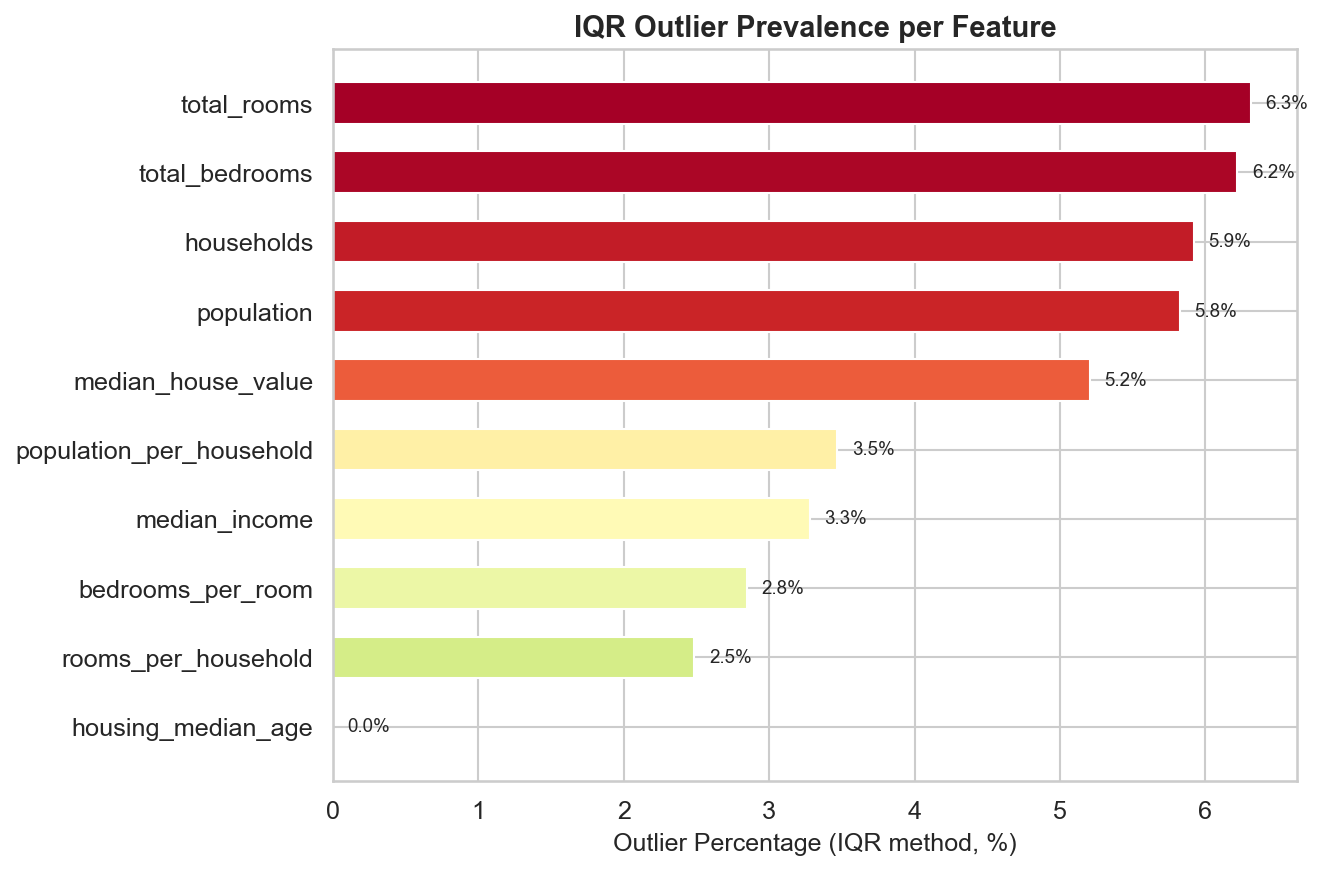

In [2]:
numeric_features = [
    'housing_median_age','total_rooms','total_bedrooms','population',
    'households','median_income','median_house_value',
    'rooms_per_household','bedrooms_per_room','population_per_household'
]

outlier_pct = {}
for col in numeric_features:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_pct[col] = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).mean() * 100

out_s = pd.Series(outlier_pct).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(out_s.index, out_s.values,
               color=plt.cm.RdYlGn_r(out_s.values / out_s.max()),
               edgecolor='white', height=0.6)
ax.set_xlabel('Outlier Percentage (IQR method, %)', fontsize=LABEL_FS)
ax.set_title('IQR Outlier Prevalence per Feature', fontsize=TITLE_FS, fontweight='bold')
for bar, val in zip(bars, out_s.values):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../../data/visualize/plot04_01_iqr_outliers.png', dpi=FIG_DPI)
plt.show()

---
### 📊 PLOT 2 — Z-Score Outlier Map (Geographic)
**What it shows:** California map scatter where red dots are districts with |z| > 3 on `median_house_value`.  
**Presentation use:** Spatially locates extreme-price outliers — mostly coastal metros like SF and LA.

Outlier districts (|z|>3): 0 / 20433 (0.0%)


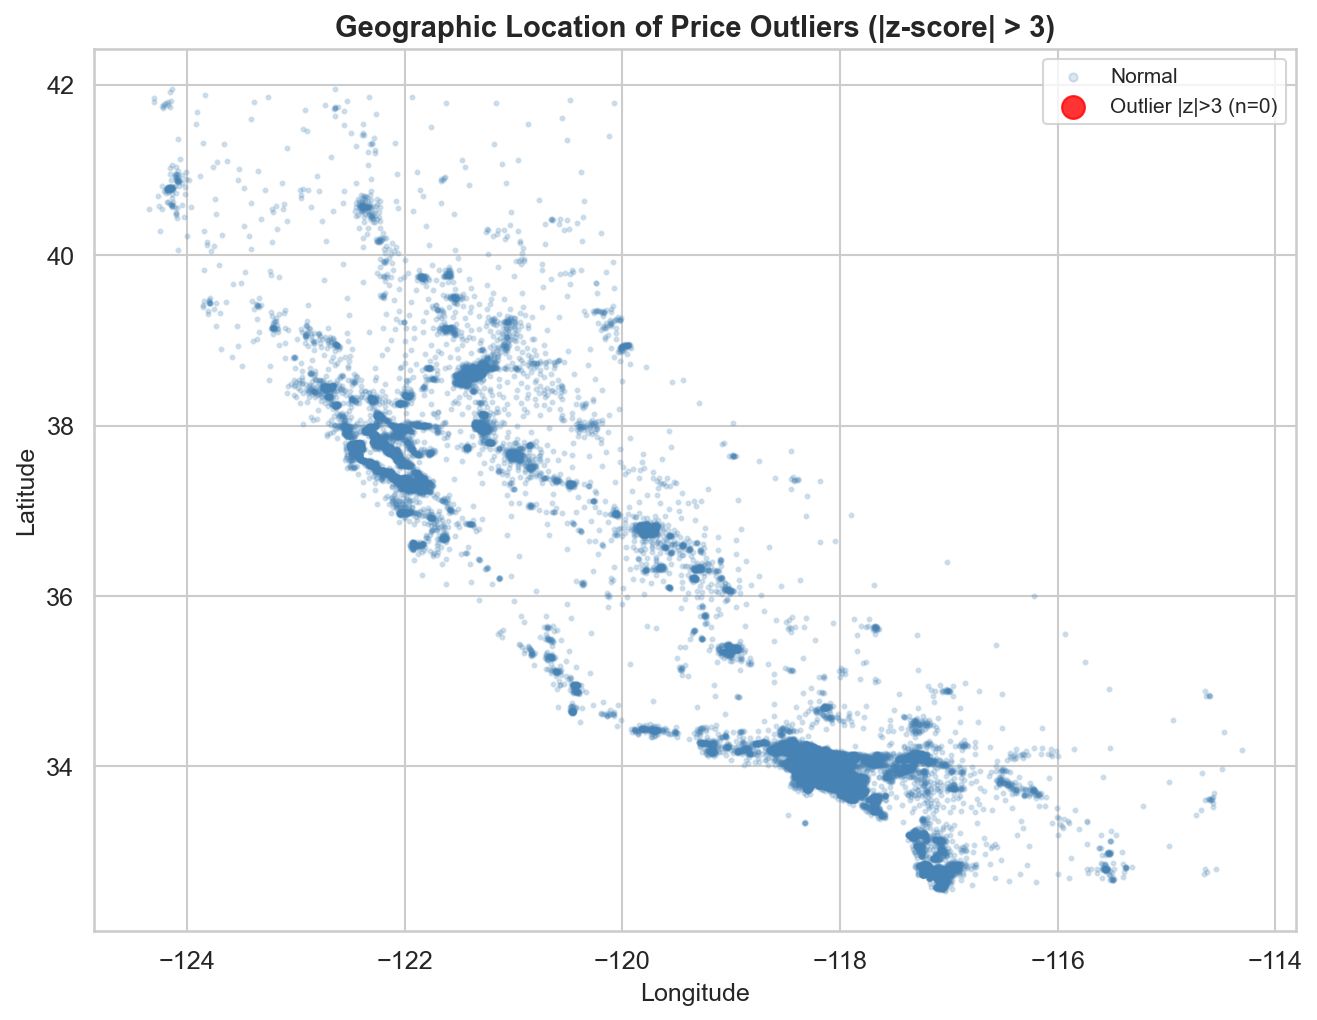

In [3]:
z_scores = np.abs(stats.zscore(df['median_house_value']))
df['is_outlier'] = z_scores > 3
print(f'Outlier districts (|z|>3): {df["is_outlier"].sum()} / {len(df)} ({df["is_outlier"].mean()*100:.1f}%)')

fig, ax = plt.subplots(figsize=(9, 7))
normal  = df[~df['is_outlier']]
outlier = df[df['is_outlier']]

ax.scatter(normal['longitude'], normal['latitude'],
           s=4, alpha=0.2, color='steelblue', label='Normal')
ax.scatter(outlier['longitude'], outlier['latitude'],
           s=30, alpha=0.8, color='red', label=f'Outlier |z|>3 (n={len(outlier)})', zorder=5)
ax.set_xlabel('Longitude', fontsize=LABEL_FS)
ax.set_ylabel('Latitude', fontsize=LABEL_FS)
ax.set_title('Geographic Location of Price Outliers (|z-score| > 3)',
             fontsize=TITLE_FS, fontweight='bold')
ax.legend(fontsize=10, markerscale=2)
plt.tight_layout()
plt.savefig('../../data/visualize/plot04_02_zscore_outlier_map.png', dpi=FIG_DPI)
plt.show()

---
## 2 · Distribution Fitting
### 📊 PLOT 3 — Target Distribution Fitting (Log-Normal vs Normal)
**What it shows:** Histogram of `median_house_value` overlaid with fitted Normal and Log-Normal PDFs.  
**Presentation use:** Justifies the need for log-scaling or tree-based models; the log-normal fit tracks the data much better than a symmetric normal.

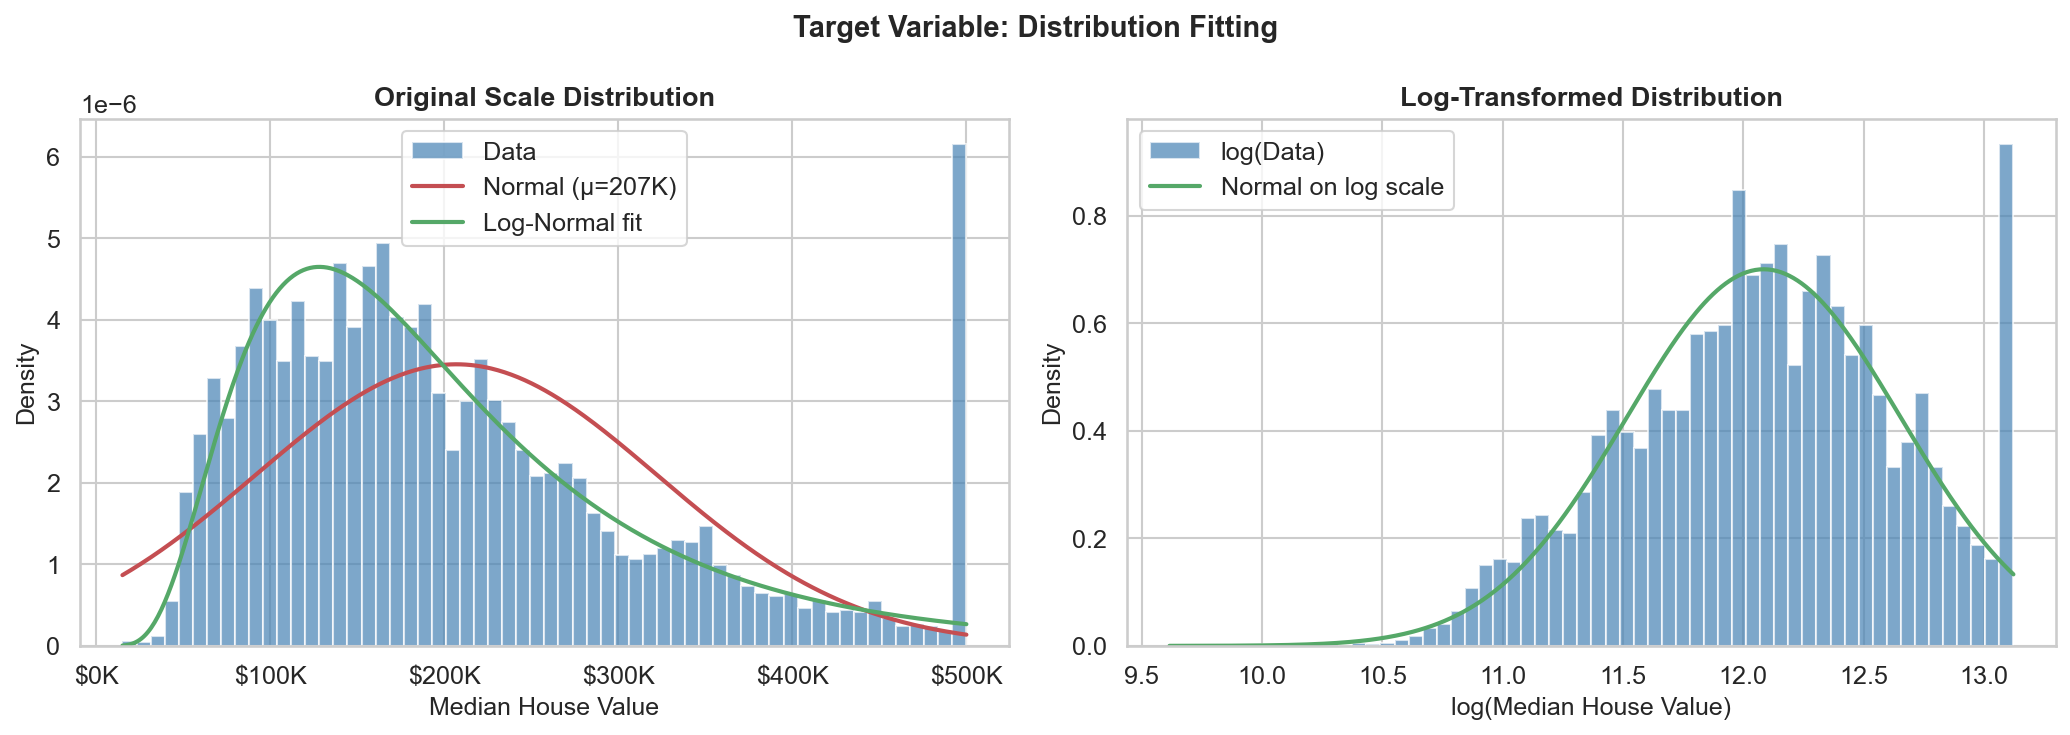

In [4]:
vals = df['median_house_value'].values
log_vals = np.log(vals)

mu_n, std_n         = stats.norm.fit(vals)
shape_ln, loc_ln, scale_ln = stats.lognorm.fit(vals, floc=0)

x_range = np.linspace(vals.min(), vals.max(), 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original scale
ax = axes[0]
ax.hist(vals, bins=60, density=True, color='steelblue', alpha=0.7, edgecolor='white', label='Data')
ax.plot(x_range, stats.norm.pdf(x_range, mu_n, std_n),
        'r-', lw=2, label=f'Normal (μ={mu_n/1e3:.0f}K)')
ax.plot(x_range, stats.lognorm.pdf(x_range, shape_ln, loc_ln, scale_ln),
        'g-', lw=2, label='Log-Normal fit')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.set_xlabel('Median House Value', fontsize=LABEL_FS)
ax.set_ylabel('Density', fontsize=LABEL_FS)
ax.set_title('Original Scale Distribution', fontsize=13, fontweight='bold')
ax.legend()

# Log scale
ax2 = axes[1]
ax2.hist(log_vals, bins=60, density=True, color='steelblue', alpha=0.7, edgecolor='white', label='log(Data)')
mu_l, std_l = log_vals.mean(), log_vals.std()
x_log = np.linspace(log_vals.min(), log_vals.max(), 400)
ax2.plot(x_log, stats.norm.pdf(x_log, mu_l, std_l), 'g-', lw=2, label='Normal on log scale')
ax2.set_xlabel('log(Median House Value)', fontsize=LABEL_FS)
ax2.set_ylabel('Density', fontsize=LABEL_FS)
ax2.set_title('Log-Transformed Distribution', fontsize=13, fontweight='bold')
ax2.legend()

fig.suptitle('Target Variable: Distribution Fitting', fontsize=TITLE_FS, fontweight='bold')
plt.tight_layout()
plt.savefig('../../data/visualize/plot04_03_distribution_fitting.png', dpi=FIG_DPI)
plt.show()

---
### 📊 PLOT 4 — Q-Q Plot (Target vs Normal)
**What it shows:** Quantile-quantile plot comparing `median_house_value` quantiles against a theoretical normal.  
**Presentation use:** The S-curve and flat right tail confirm the data is right-skewed and has a hard upper ceiling — non-normality affects linear model assumptions.

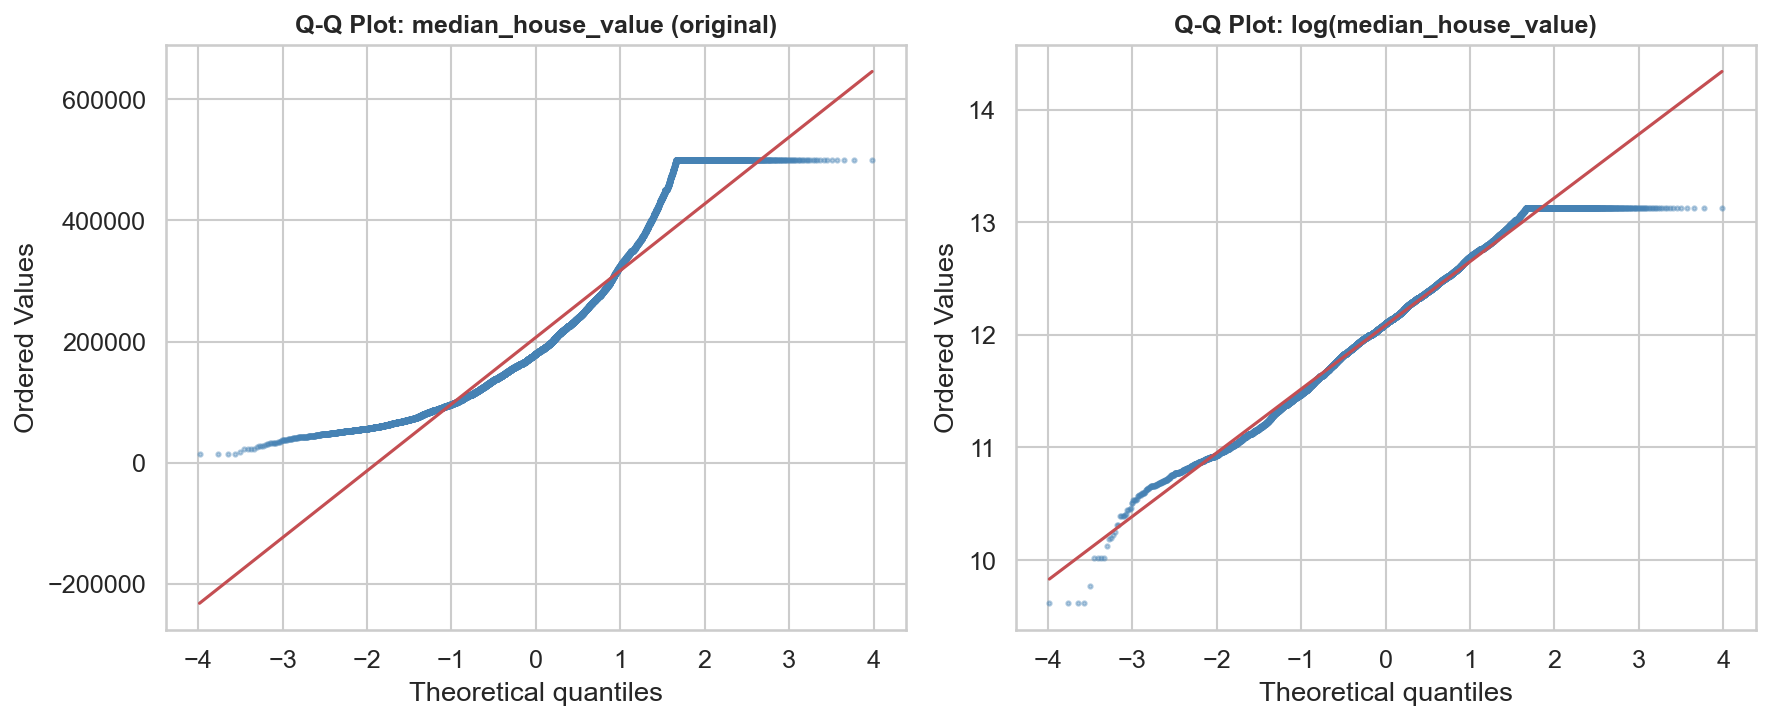

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

stats.probplot(vals, dist='norm', plot=axes[0])
axes[0].set_title('Q-Q Plot: median_house_value (original)', fontsize=12, fontweight='bold')
axes[0].get_lines()[0].set(markersize=2, alpha=0.4, color='steelblue')

stats.probplot(np.log1p(vals), dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot: log(median_house_value)', fontsize=12, fontweight='bold')
axes[1].get_lines()[0].set(markersize=2, alpha=0.4, color='steelblue')

plt.tight_layout()
plt.savefig('../../data/visualize/plot04_04_qq_plots.png', dpi=FIG_DPI)
plt.show()

---
## 3 · Geographic Price Clustering
### 📊 PLOT 5 — KMeans Geographic Clusters on California Map
**What it shows:** 6 geographic clusters from KMeans on (latitude, longitude), with mean house value per cluster annotated.  
**Presentation use:** Reveals distinct regional housing markets (Bay Area, LA Metro, Inland Valley, etc.) without needing manual labels.

Mean house value per geo cluster:
geo_cluster
1    $262,935
0    $230,044
4    $177,836
3    $125,854
2    $122,759
5     $92,191
Name: median_house_value, dtype: str


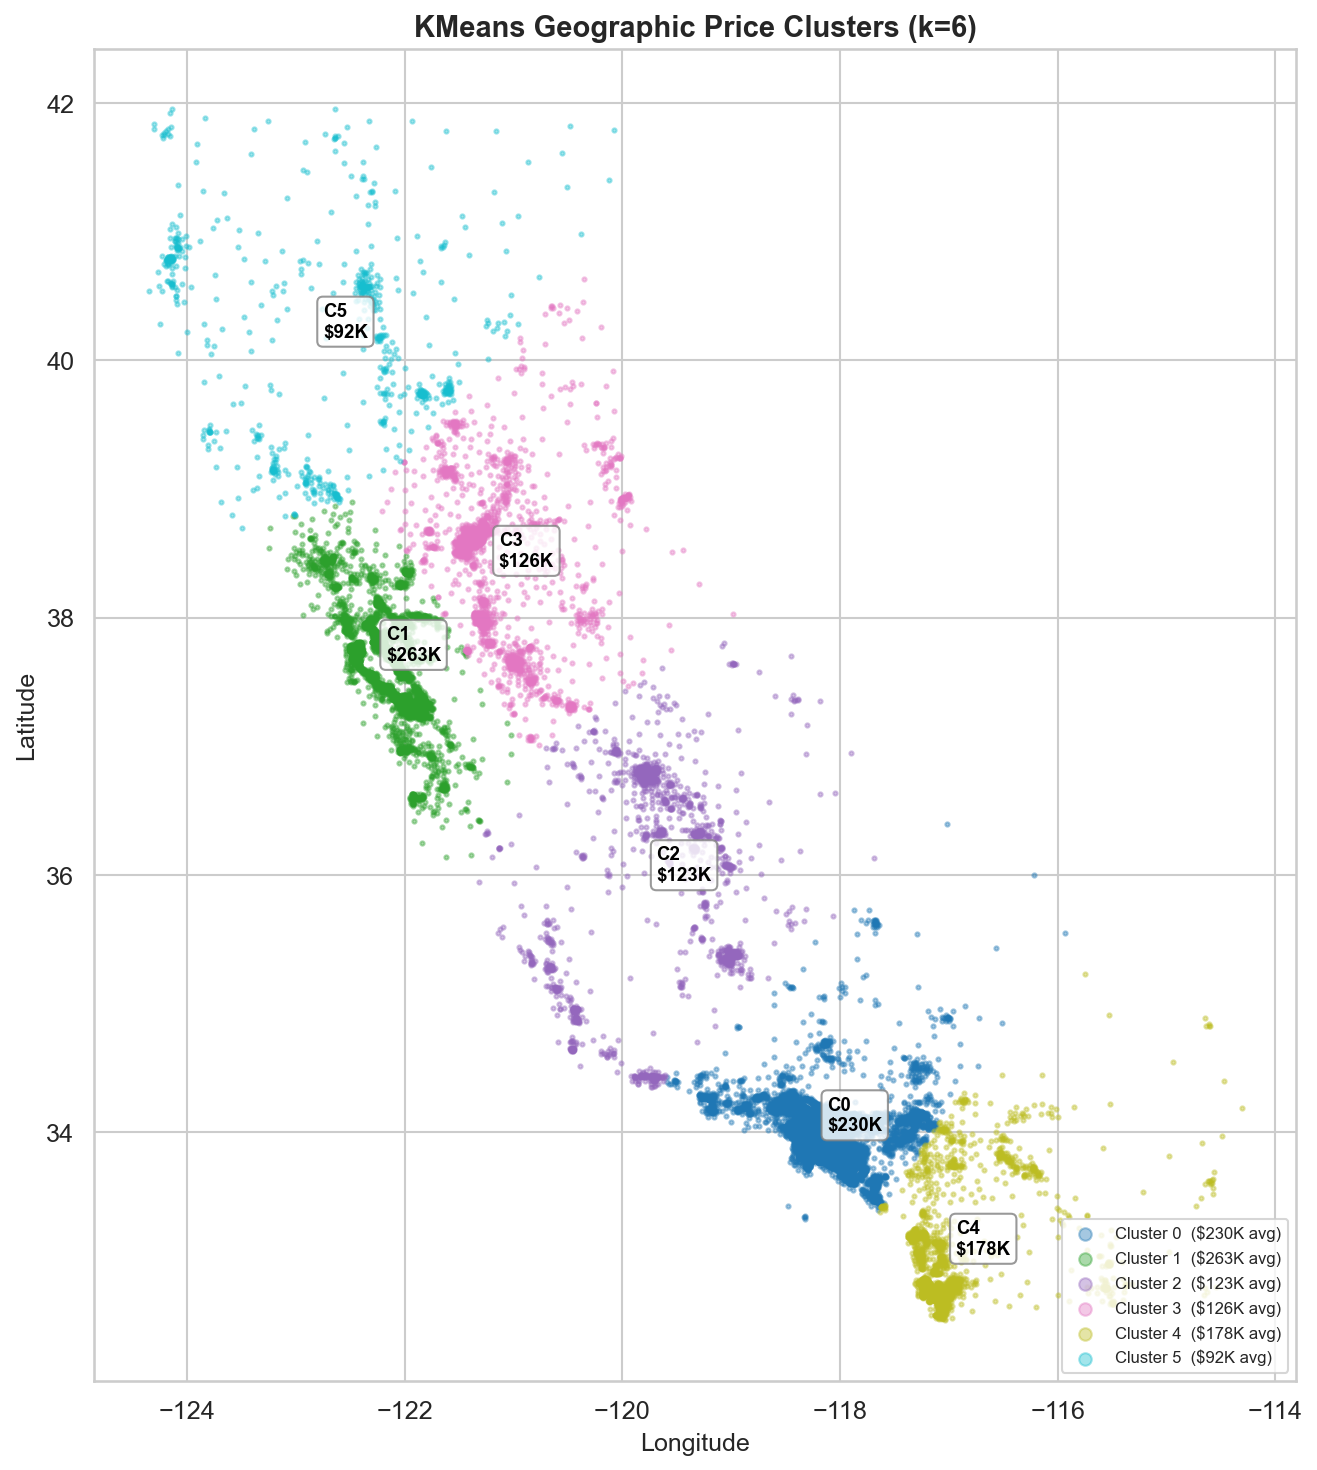

In [6]:
K = 6
coords = df[['latitude','longitude']].values
km = KMeans(n_clusters=K, random_state=42, n_init=10)
df['geo_cluster'] = km.fit_predict(coords)

cluster_means = df.groupby('geo_cluster')['median_house_value'].mean()
sorted_clusters = cluster_means.sort_values(ascending=False)
print('Mean house value per geo cluster:')
print(sorted_clusters.apply(lambda x: f'${x:,.0f}'))

fig, ax = plt.subplots(figsize=(9, 10))
cluster_palette = plt.cm.tab10(np.linspace(0, 1, K))

for c in range(K):
    mask = df['geo_cluster'] == c
    mean_val = cluster_means[c]
    ax.scatter(df.loc[mask,'longitude'], df.loc[mask,'latitude'],
               s=4, alpha=0.4, color=cluster_palette[c],
               label=f'Cluster {c}  (${mean_val/1e3:.0f}K avg)')

# Annotate cluster centroids
centers = km.cluster_centers_
for c in range(K):
    ax.annotate(f'C{c}\n${cluster_means[c]/1e3:.0f}K',
                xy=(centers[c,1], centers[c,0]),
                fontsize=9, fontweight='bold', color='black',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.8))

ax.set_xlabel('Longitude', fontsize=LABEL_FS)
ax.set_ylabel('Latitude', fontsize=LABEL_FS)
ax.set_title(f'KMeans Geographic Price Clusters (k={K})',
             fontsize=TITLE_FS, fontweight='bold')
ax.legend(loc='lower right', fontsize=8, markerscale=3)
plt.tight_layout()
plt.savefig('../../data/visualize/plot04_05_geo_clusters.png', dpi=FIG_DPI)
plt.show()

---
### 📊 PLOT 6 — Geographic Price Heatmap (Grid Binning)
**What it shows:** California grid where each cell is coloured by mean house value in that lat/long bin.  
**Presentation use:** Provides a polished, map-like view of price geography — instantly readable for audiences unfamiliar with scatter plots.

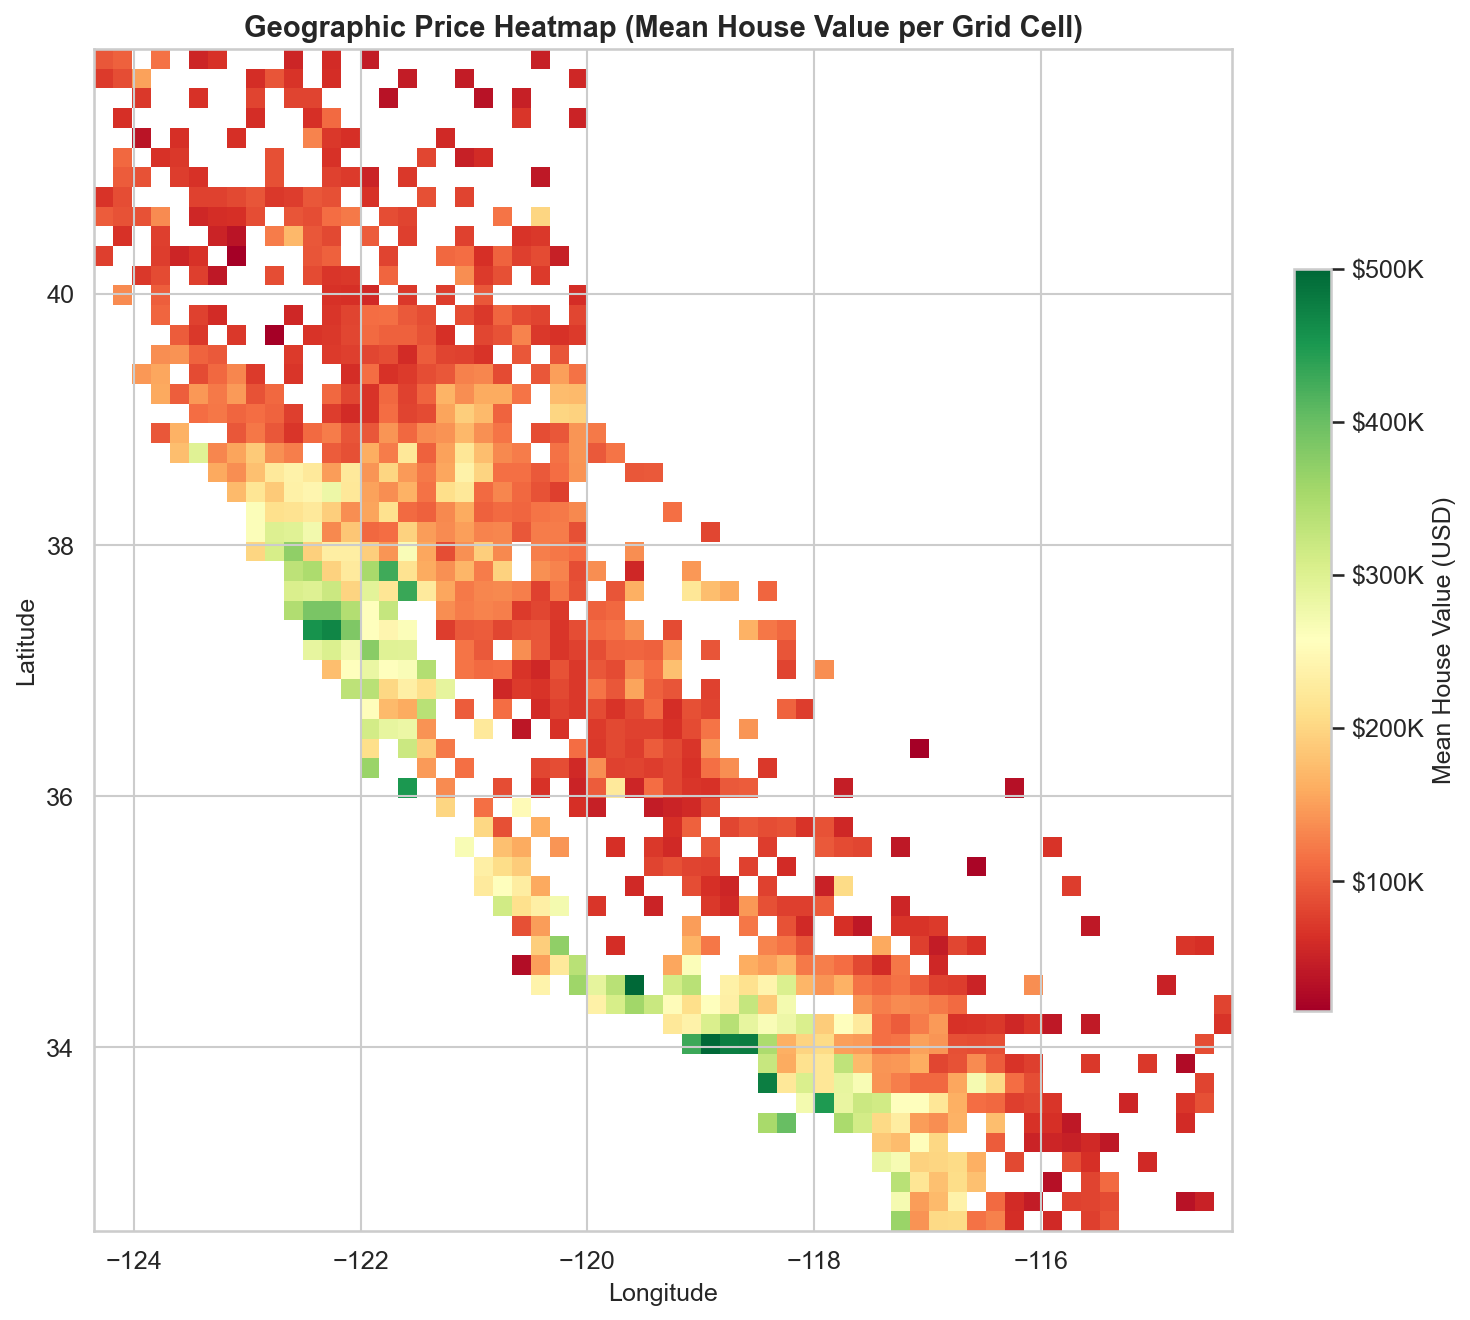

In [7]:
# Create 60x60 grid of mean house values
lat_bins  = np.linspace(df['latitude'].min(),  df['latitude'].max(),  61)
lon_bins  = np.linspace(df['longitude'].min(), df['longitude'].max(), 61)

df['lat_bin'] = pd.cut(df['latitude'],  bins=lat_bins,  labels=False)
df['lon_bin'] = pd.cut(df['longitude'], bins=lon_bins,  labels=False)

grid = df.groupby(['lat_bin','lon_bin'])['median_house_value'].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(
    grid.values,
    aspect='auto',
    origin='lower',
    cmap='RdYlGn',
    extent=[df['longitude'].min(), df['longitude'].max(),
            df['latitude'].min(),  df['latitude'].max()]
)
cbar = fig.colorbar(im, ax=ax, fraction=0.03)
cbar.set_label('Mean House Value (USD)', fontsize=LABEL_FS)
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.set_xlabel('Longitude', fontsize=LABEL_FS)
ax.set_ylabel('Latitude',  fontsize=LABEL_FS)
ax.set_title('Geographic Price Heatmap (Mean House Value per Grid Cell)',
             fontsize=TITLE_FS, fontweight='bold')
plt.tight_layout()
plt.savefig('../../data/visualize/plot04_06_price_heatmap_grid.png', dpi=FIG_DPI)
plt.show()

---
## 4 · Statistical Group Comparisons
### 📊 PLOT 7 — ANOVA: House Price by Ocean Proximity
**What it shows:** One-way ANOVA F-statistic, p-value, and violin comparison of price distributions across ocean proximity groups.  
**Presentation use:** Statistically confirms the visual differences — the price difference between groups is not by chance.

One-Way ANOVA  →  F = 1594.71,  p = 0.00e+00


C:\Users\TDV\AppData\Local\Temp\ipykernel_29244\2229071917.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


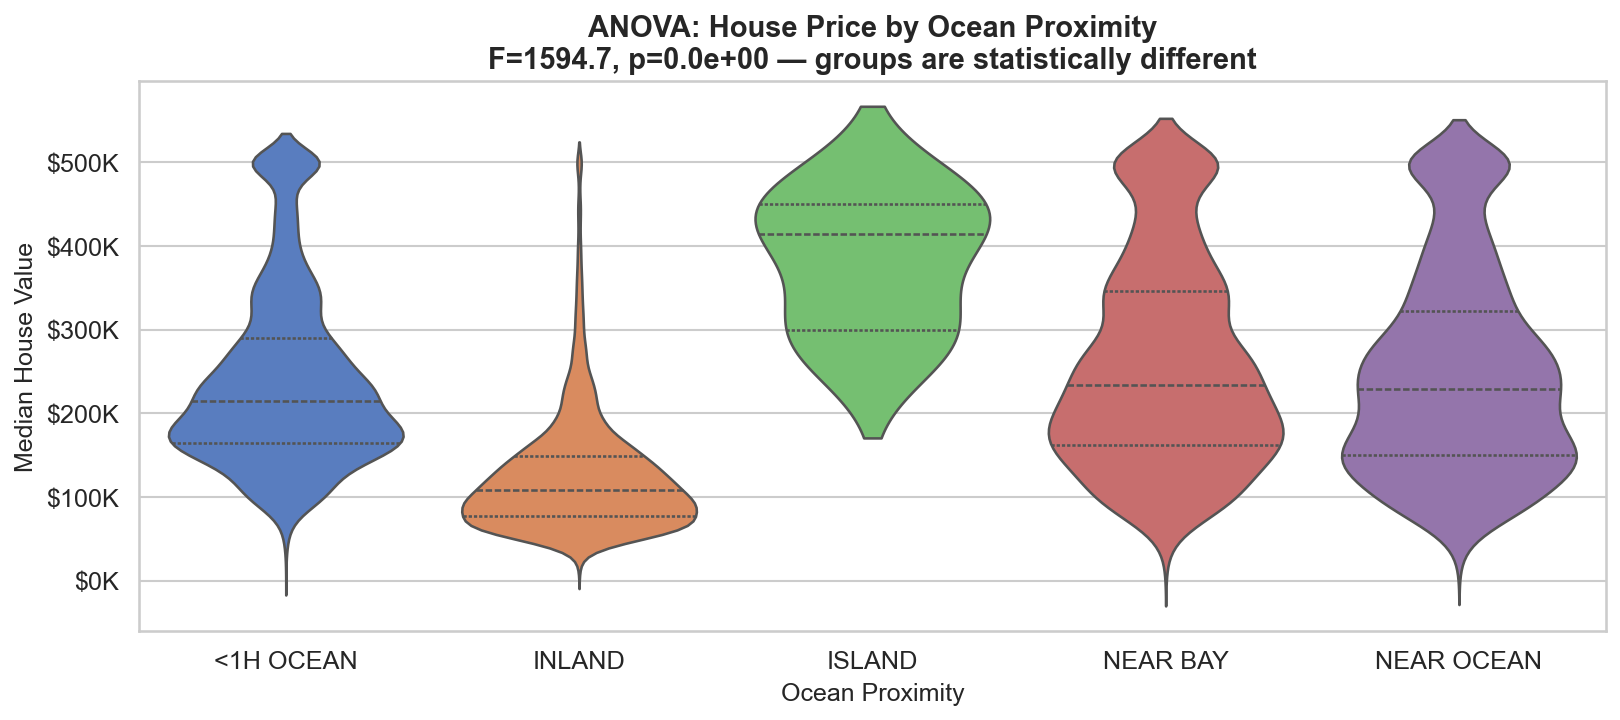

In [8]:
prox_order = sorted(df['ocean_proximity'].unique())
groups = [df.loc[df['ocean_proximity']==g, 'median_house_value'].values for g in prox_order]
f_stat, p_val = stats.f_oneway(*groups)
print(f'One-Way ANOVA  →  F = {f_stat:.2f},  p = {p_val:.2e}')

fig, ax = plt.subplots(figsize=(11, 5))
sns.violinplot(
    data=df, x='ocean_proximity', y='median_house_value',
    order=prox_order, palette='muted', inner='quartile', ax=ax
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.set_xlabel('Ocean Proximity', fontsize=LABEL_FS)
ax.set_ylabel('Median House Value', fontsize=LABEL_FS)
ax.set_title(f'ANOVA: House Price by Ocean Proximity\n'
             f'F={f_stat:.1f}, p={p_val:.1e} — groups are statistically different',
             fontsize=TITLE_FS, fontweight='bold')
plt.tight_layout()
plt.savefig('../../data/visualize/plot04_07_anova_ocean_proximity.png', dpi=FIG_DPI)
plt.show()

---
### 📊 PLOT 8 — Cluster Profile Radar Chart
**What it shows:** Radar/spider chart comparing normalised mean values of key features across geographic clusters.  
**Presentation use:** Makes it easy to communicate the 'personality' of each housing market region in a single slide.

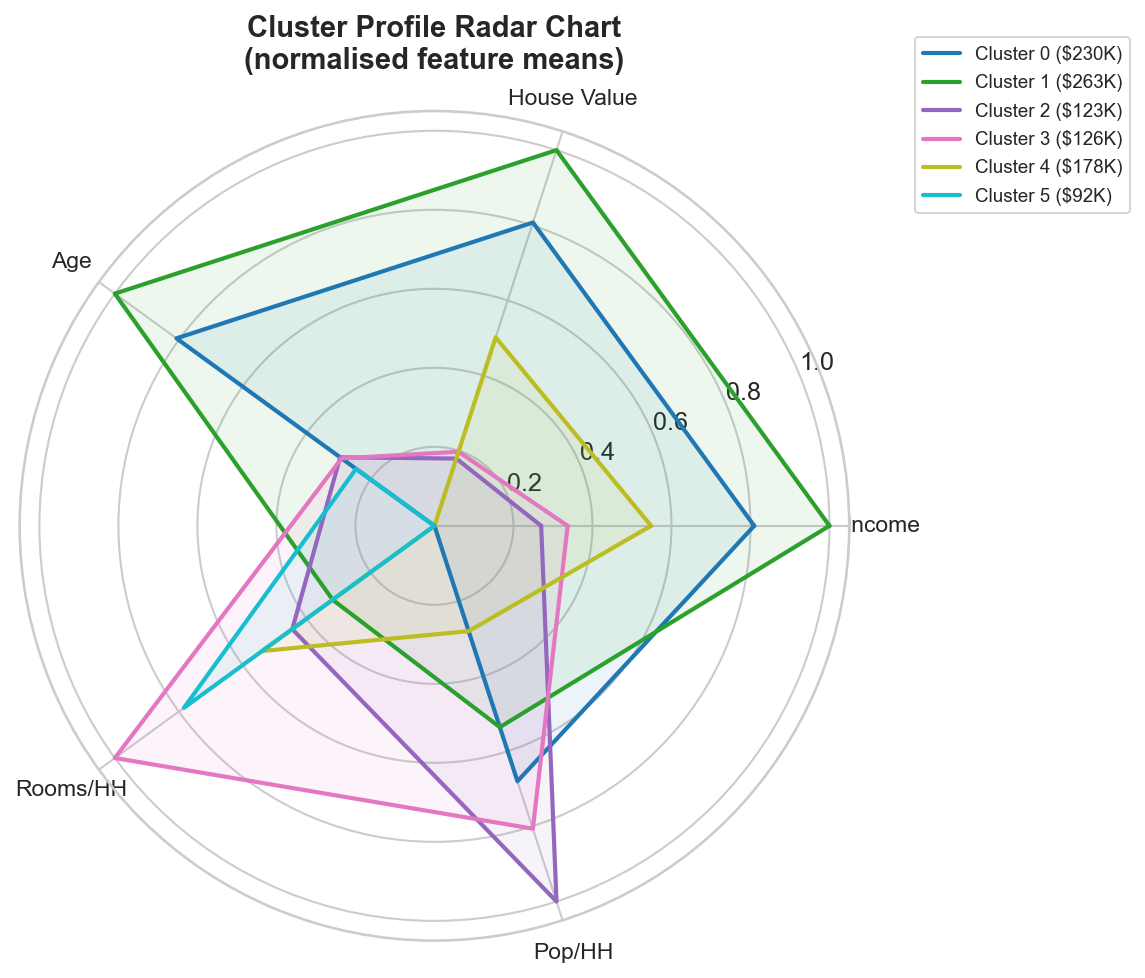

In [9]:
radar_feats = ['median_income','median_house_value','housing_median_age',
               'rooms_per_household','population_per_household']
cluster_profile = df.groupby('geo_cluster')[radar_feats].mean()

# Normalise 0-1
norm_profile = (cluster_profile - cluster_profile.min()) / \
               (cluster_profile.max() - cluster_profile.min())

labels = ['Income','House Value','Age','Rooms/HH','Pop/HH']
N = len(labels)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = plt.cm.tab10(np.linspace(0, 1, K))

for c in range(K):
    vals_r = norm_profile.loc[c].tolist() + norm_profile.loc[c].tolist()[:1]
    ax.plot(angles, vals_r, linewidth=2, color=colors[c],
            label=f'Cluster {c} (${cluster_means[c]/1e3:.0f}K)')
    ax.fill(angles, vals_r, alpha=0.08, color=colors[c])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_title('Cluster Profile Radar Chart\n(normalised feature means)',
             fontsize=TITLE_FS, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig('../../data/visualize/plot04_08_cluster_radar.png', dpi=FIG_DPI)
plt.show()

---
### 📊 PLOT 9 — Housing Age Cohort Analysis
**What it shows:** Price distributions grouped into housing age cohorts (pre-war, post-war, modern, etc.).  
**Presentation use:** Shows that newer housing is not necessarily pricier — location dominates age effects.

C:\Users\TDV\AppData\Local\Temp\ipykernel_29244\1322852456.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


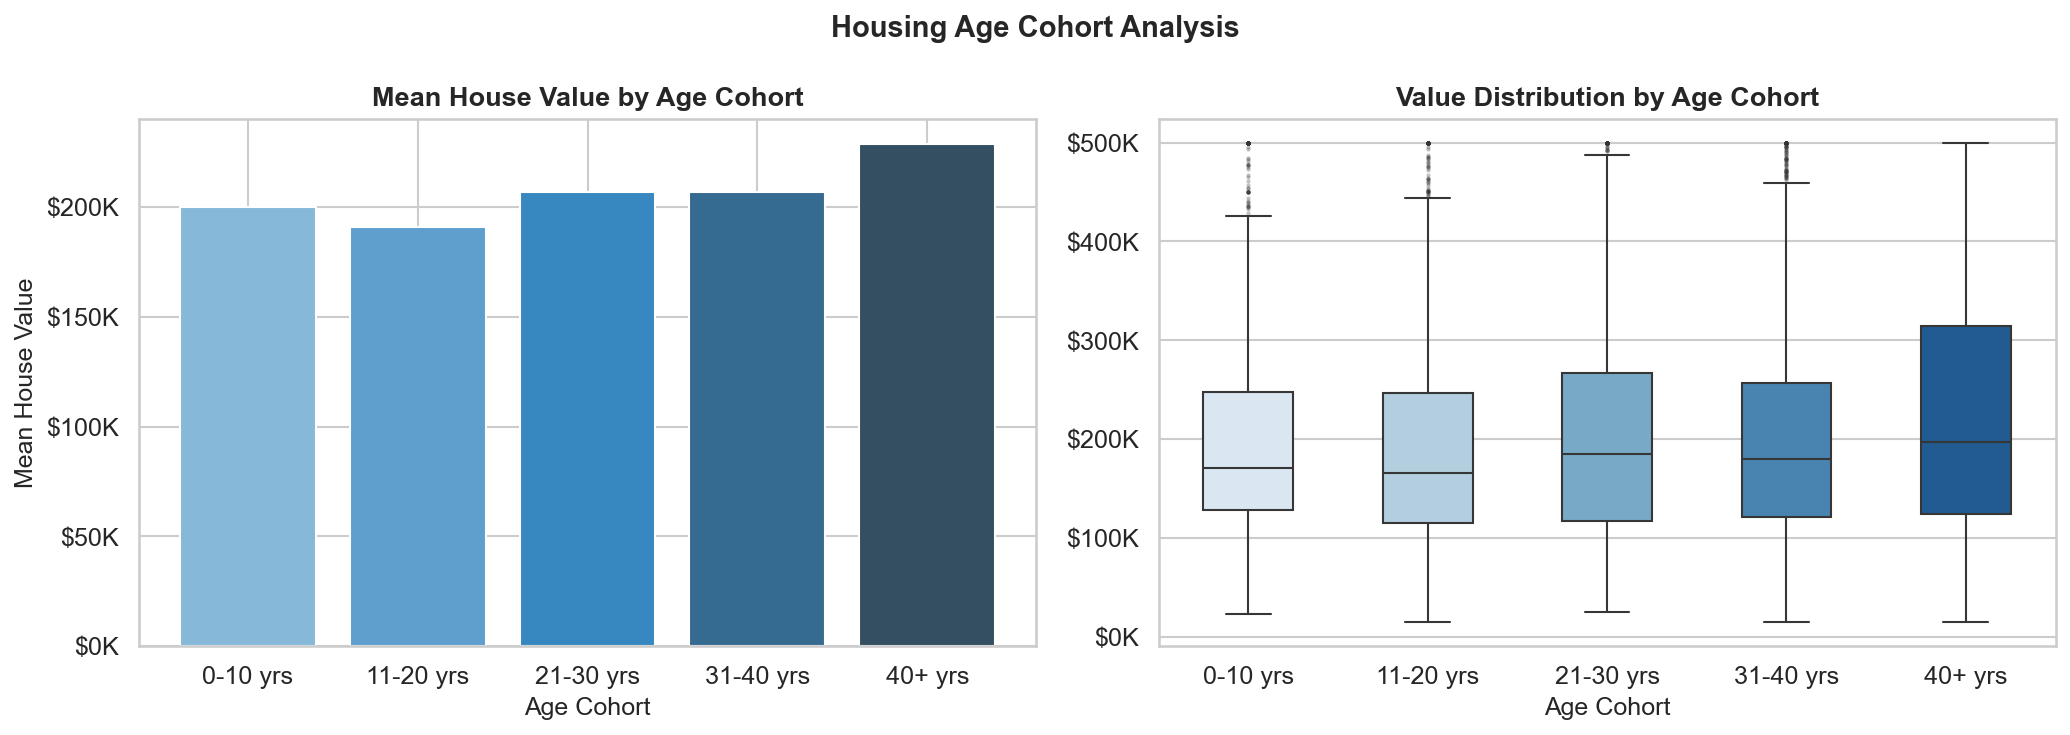

In [10]:
age_bins   = [0, 10, 20, 30, 40, 52]
age_labels = ['0-10 yrs','11-20 yrs','21-30 yrs','31-40 yrs','40+ yrs']
df['age_cohort'] = pd.cut(df['housing_median_age'], bins=age_bins, labels=age_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: mean value per cohort
cohort_mean = df.groupby('age_cohort')['median_house_value'].mean()
axes[0].bar(cohort_mean.index, cohort_mean.values,
            color=sns.color_palette('Blues_d', len(age_labels)), edgecolor='white')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[0].set_xlabel('Age Cohort', fontsize=LABEL_FS)
axes[0].set_ylabel('Mean House Value', fontsize=LABEL_FS)
axes[0].set_title('Mean House Value by Age Cohort', fontsize=13, fontweight='bold')

# Right: box per cohort
sns.boxplot(
    data=df, x='age_cohort', y='median_house_value',
    order=age_labels, palette='Blues', ax=axes[1], width=0.5,
    flierprops=dict(marker='.', markersize=2, alpha=0.3)
)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[1].set_xlabel('Age Cohort', fontsize=LABEL_FS)
axes[1].set_ylabel('')
axes[1].set_title('Value Distribution by Age Cohort', fontsize=13, fontweight='bold')

fig.suptitle('Housing Age Cohort Analysis', fontsize=TITLE_FS, fontweight='bold')
plt.tight_layout()
plt.savefig('../../data/visualize/plot04_09_age_cohort_analysis.png', dpi=FIG_DPI)
plt.show()

---
### 📊 PLOT 10 — Elbow Plot for KMeans Cluster Selection
**What it shows:** Within-cluster sum of squares (WCSS) vs number of clusters k=1..12.  
**Presentation use:** Justifies the choice of k=6 geographic clusters; the elbow at k=5-6 validates this segmentation.

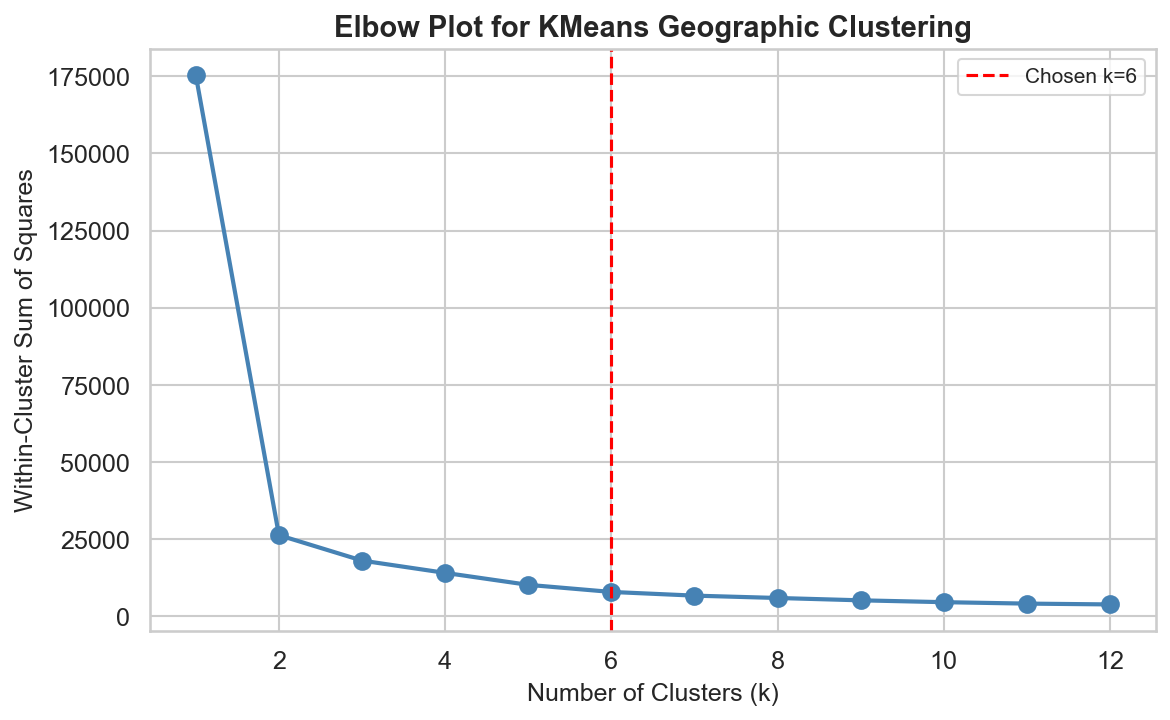

In [11]:
inertias = []
k_range  = range(1, 13)

for k in k_range:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_tmp.fit(coords)
    inertias.append(km_tmp.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_range, inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.axvline(6, color='red', linestyle='--', linewidth=1.5, label='Chosen k=6')
ax.set_xlabel('Number of Clusters (k)', fontsize=LABEL_FS)
ax.set_ylabel('Within-Cluster Sum of Squares', fontsize=LABEL_FS)
ax.set_title('Elbow Plot for KMeans Geographic Clustering',
             fontsize=TITLE_FS, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../../data/visualize/plot04_10_elbow_kmeans.png', dpi=FIG_DPI)
plt.show()

---
## Summary of Notebook 04

| Plot | File | Key Takeaway |
|------|------|--------------|
| 1 | plot04_01_iqr_outliers | `population_per_household` most outlier-prone |
| 2 | plot04_02_zscore_outlier_map | Extreme-price outliers cluster in coastal metros |
| 3 | plot04_03_distribution_fitting | Target is log-normal; hard $500K ceiling is an artefact |
| 4 | plot04_04_qq_plots | Log transform improves normality substantially |
| 5 | plot04_05_geo_clusters | 6 distinct regional markets identified |
| 6 | plot04_06_price_heatmap_grid | Bay Area / LA visually stand out as high-price zones |
| 7 | plot04_07_anova_ocean_proximity | Ocean proximity groups are statistically different (p<<0.05) |
| 8 | plot04_08_cluster_radar | Each region has a distinct feature 'personality' |
| 9 | plot04_09_age_cohort_analysis | Age has a non-linear effect on price; location dominates |
| 10 | plot04_10_elbow_kmeans | Elbow at k=5-6 validates the clustering choice |